# Análise Exploratória — Dataset de Risco de Crédito

Este notebook analisa o dataset sintético de solicitantes de crédito gerado pelo sistema.
O objetivo é entender as distribuições, correlações e a relação entre as features e a inadimplência.

In [10]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data.generator import generate_dataset

sns.set_theme(style='whitegrid', palette='Set2')
pd.set_option('display.max_columns', 20)

df = generate_dataset(n_samples=10_000, seed=42)
print(f'Shape: {df.shape}')
df.head()

Shape: (10000, 11)


,idade,renda_mensal,tempo_emprego_meses,num_dependentes,valor_solicitado,divida_existente,atrasos_12m,score_externo,tipo_residencia,finalidade_emprestimo,inadimplente
0,22.0,2541.84,259.0,1.0,8909.50,968.50,0.0,595.365536,familiar,educacao,0
1,58.0,3551.81,43.0,1.0,12558.16,4072.75,0.0,900.000000,financiada,negocios,0
2,52.0,5786.02,85.0,0.0,2472.24,909.57,1.0,389.053983,alugada,pessoal,0
3,40.0,3371.15,271.0,0.0,5249.95,3428.80,0.0,669.034075,propria,negocios,0
4,40.0,4158.79,290.0,0.0,2144.67,3452.98,0.0,819.885898,alugada,imovel,0


## Visão Geral do Dataset

In [11]:
print('=== Info ===')
print(f'Linhas: {len(df)}')
print(f'Colunas: {len(df.columns)}')
print(f'Nulos: {df.isnull().sum().sum()}')
print(f'\nTaxa de inadimplência: {df.inadimplente.mean():.2%}')
print(f'Adimplentes: {(df.inadimplente == 0).sum():,}')
print(f'Inadimplentes: {(df.inadimplente == 1).sum():,}')

df.describe().round(2)

=== Info ===
Linhas: 10000
Colunas: 11
Nulos: 0

Taxa de inadimplência: 17.67%
Adimplentes: 8,233
Inadimplentes: 1,767


,idade,renda_mensal,tempo_emprego_meses,num_dependentes,valor_solicitado,divida_existente,atrasos_12m,score_externo,inadimplente
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0,10000.00,10000.00
mean,43.31,5890.73,179.34,1.21,10953.68,5003.52,0.8,599.27,0.18
std,14.94,3946.97,104.90,1.10,11238.99,5025.83,0.9,120.67,0.38
min,18.00,353.02,0.00,0.00,384.52,0.16,0.0,200.00,0.00
25%,30.00,3288.63,88.00,0.00,4696.94,1454.95,0.0,516.92,0.00
50%,43.00,4855.30,180.00,1.00,7907.07,3485.42,1.0,598.39,0.00
75%,56.00,7334.07,269.25,2.00,13511.30,6903.88,1.0,681.96,0.00
max,69.00,59322.55,359.00,6.00,444981.59,51363.02,6.0,900.00,1.00


## Distribuição da Variável Alvo

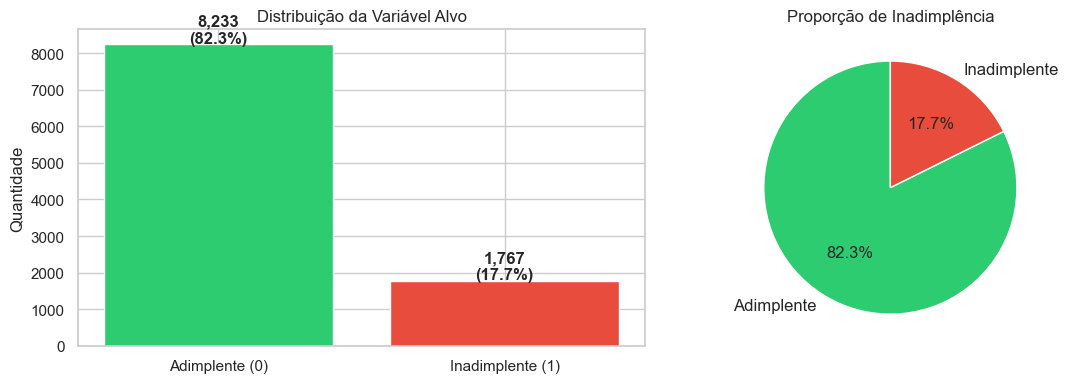

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
counts = df['inadimplente'].value_counts()
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(['Adimplente (0)', 'Inadimplente (1)'], counts.values, color=colors)
axes[0].set_title('Distribuição da Variável Alvo')
axes[0].set_ylabel('Quantidade')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, f'{v:,}\n({v/len(df):.1%})', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Adimplente', 'Inadimplente'], 
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Proporção de Inadimplência')

plt.tight_layout()
plt.show()

## Distribuição das Variáveis Numéricas

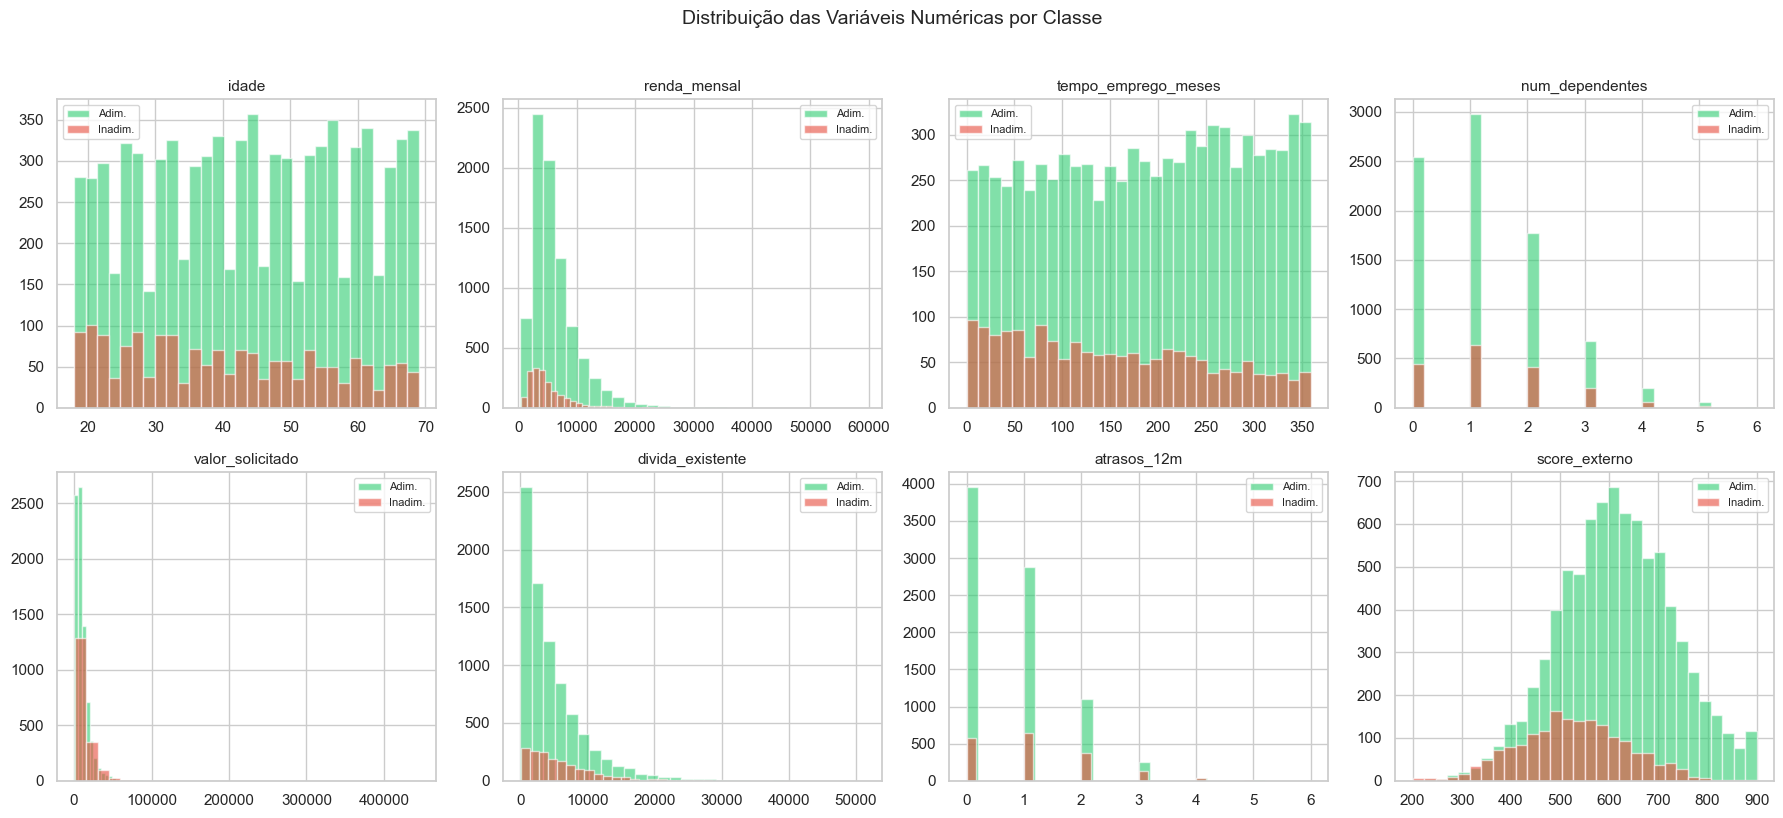

In [13]:
numeric_cols = ['idade', 'renda_mensal', 'tempo_emprego_meses', 'num_dependentes',
                'valor_solicitado', 'divida_existente', 'atrasos_12m', 'score_externo']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        lbl = 'Adim.' if label == 0 else 'Inadim.'
        axes[i].hist(df[df['inadimplente'] == label][col], bins=30, alpha=0.6, color=color, label=lbl)
    axes[i].set_title(col, fontsize=11)
    axes[i].legend(fontsize=8)

plt.suptitle('Distribuição das Variáveis Numéricas por Classe', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Variáveis Categóricas vs. Inadimplência

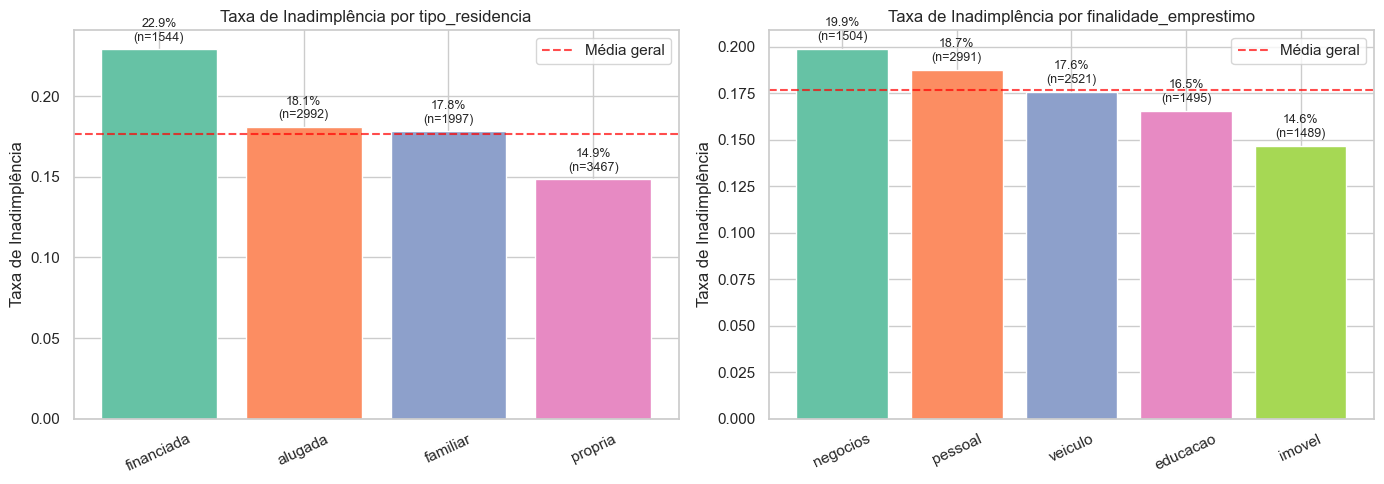

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['tipo_residencia', 'finalidade_emprestimo']):
    rates = df.groupby(col)['inadimplente'].agg(['mean', 'count']).sort_values('mean', ascending=False)
    bars = axes[i].bar(rates.index, rates['mean'], color=sns.color_palette('Set2', len(rates)))
    axes[i].set_title(f'Taxa de Inadimplência por {col}')
    axes[i].set_ylabel('Taxa de Inadimplência')
    axes[i].tick_params(axis='x', rotation=25)
    axes[i].axhline(y=df['inadimplente'].mean(), color='red', linestyle='--', alpha=0.7, label='Média geral')
    axes[i].legend()
    for bar, (_, row) in zip(bars, rates.iterrows()):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{row["mean"]:.1%}\n(n={int(row["count"])})', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Matriz de Correlação

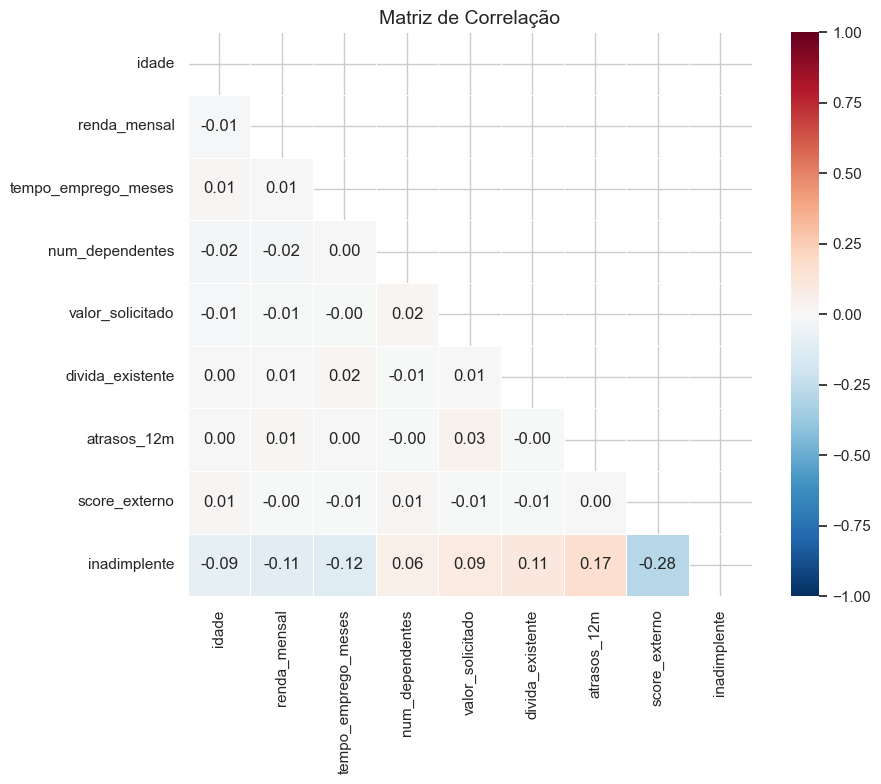


Correlação com inadimplência:
  score_externo                  -0.282  (↓ risco)
  atrasos_12m                    +0.166  (↑ risco)
  tempo_emprego_meses            -0.124  (↓ risco)
  renda_mensal                   -0.111  (↓ risco)
  divida_existente               +0.108  (↑ risco)
  valor_solicitado               +0.092  (↑ risco)
  idade                          -0.087  (↓ risco)
  num_dependentes                +0.059  (↑ risco)


In [15]:
corr_cols = numeric_cols + ['inadimplente']
corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlação', fontsize=14)
plt.tight_layout()
plt.show()

print('\nCorrelação com inadimplência:')
target_corr = corr['inadimplente'].drop('inadimplente').sort_values(key=abs, ascending=False)
for feat, val in target_corr.items():
    direction = '↑ risco' if val > 0 else '↓ risco'
    print(f'  {feat:30s} {val:+.3f}  ({direction})')

## Variáveis Derivadas — Análise de Risco

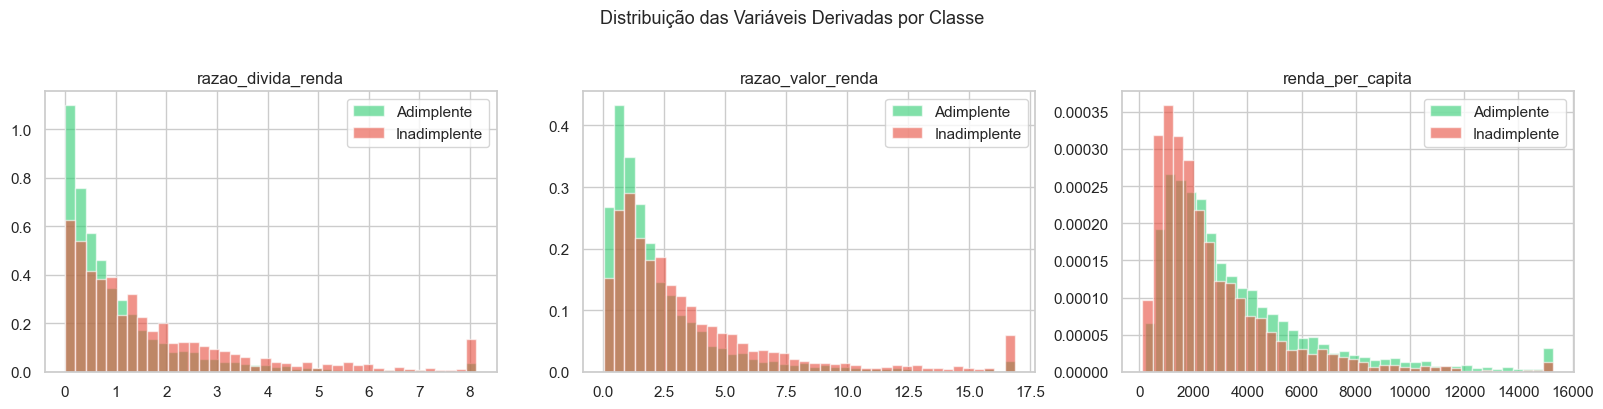

In [16]:
df['razao_divida_renda'] = df['divida_existente'] / (df['renda_mensal'] + 1)
df['razao_valor_renda'] = df['valor_solicitado'] / (df['renda_mensal'] + 1)
df['renda_per_capita'] = df['renda_mensal'] / (df['num_dependentes'] + 1)

derived = ['razao_divida_renda', 'razao_valor_renda', 'renda_per_capita']

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for i, col in enumerate(derived):
    data_0 = df[df['inadimplente'] == 0][col].clip(upper=df[col].quantile(0.99))
    data_1 = df[df['inadimplente'] == 1][col].clip(upper=df[col].quantile(0.99))
    axes[i].hist(data_0, bins=40, alpha=0.6, color='#2ecc71', label='Adimplente', density=True)
    axes[i].hist(data_1, bins=40, alpha=0.6, color='#e74c3c', label='Inadimplente', density=True)
    axes[i].set_title(col)
    axes[i].legend()

plt.suptitle('Distribuição das Variáveis Derivadas por Classe', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Análise por Faixa de Score Externo

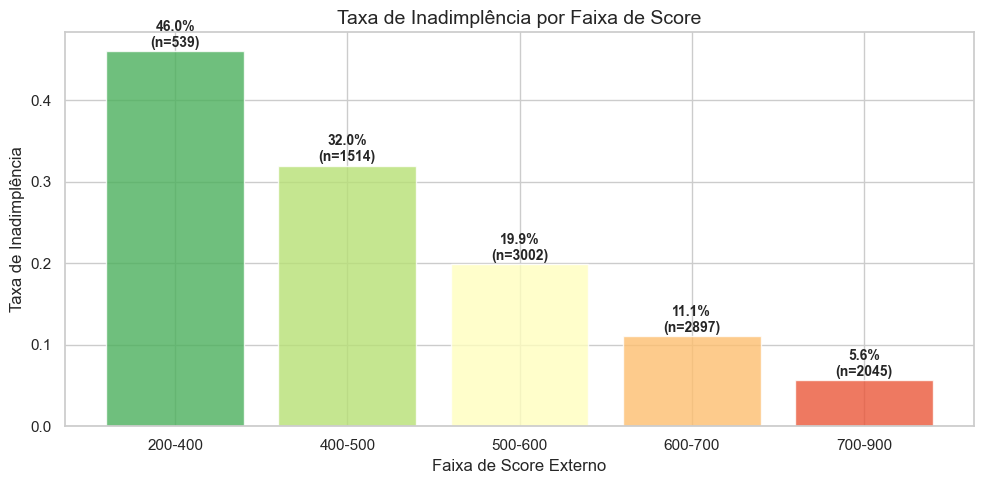

,taxa_inadimplencia,quantidade,renda_media,divida_media
faixa_score,,,,
200-400,0.4601,539,5840.8243,5335.2730
400-500,0.3197,1514,5867.4625,5207.2866
500-600,0.1992,3002,5977.2397,4859.0604
600-700,0.1105,2897,5845.6962,4876.7475
700-900,0.0562,2045,5856.9205,5154.0830


In [17]:
df['faixa_score'] = pd.cut(df['score_externo'], bins=[200, 400, 500, 600, 700, 900],
                           labels=['200-400', '400-500', '500-600', '600-700', '700-900'])

score_analysis = df.groupby('faixa_score', observed=True).agg(
    taxa_inadimplencia=('inadimplente', 'mean'),
    quantidade=('inadimplente', 'count'),
    renda_media=('renda_mensal', 'mean'),
    divida_media=('divida_existente', 'mean'),
).round(4)

fig, ax1 = plt.subplots(figsize=(10, 5))

bars = ax1.bar(score_analysis.index, score_analysis['taxa_inadimplencia'], 
               color=sns.color_palette('RdYlGn_r', len(score_analysis)), alpha=0.8)
ax1.set_ylabel('Taxa de Inadimplência', fontsize=12)
ax1.set_xlabel('Faixa de Score Externo', fontsize=12)
ax1.set_title('Taxa de Inadimplência por Faixa de Score', fontsize=14)

for bar, (_, row) in zip(bars, score_analysis.iterrows()):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{row["taxa_inadimplencia"]:.1%}\n(n={int(row["quantidade"])})', 
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

score_analysis

## Análise Bivariada — Renda vs. Valor Solicitado

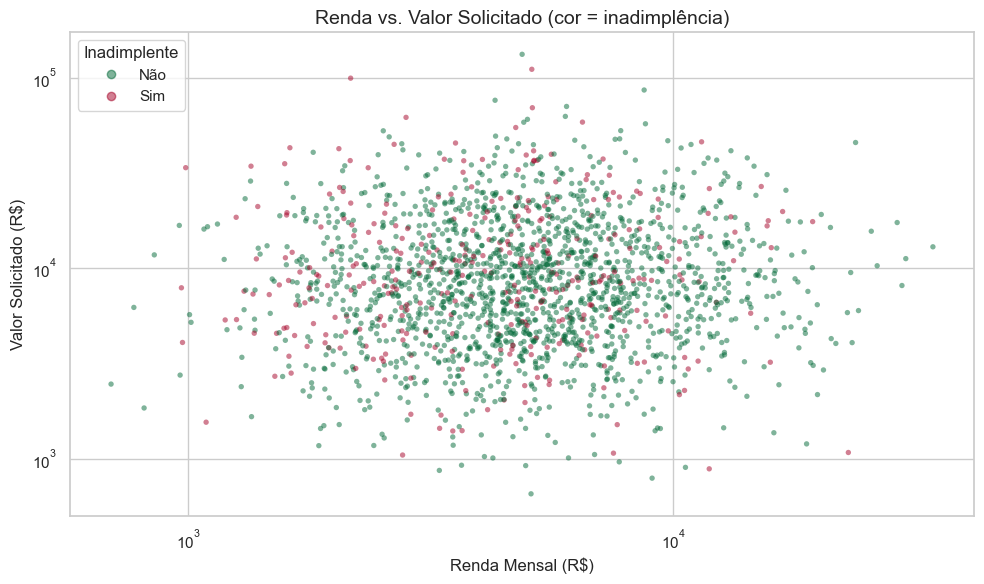

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))

sample = df.sample(2000, random_state=42)
scatter = ax.scatter(
    sample['renda_mensal'], sample['valor_solicitado'],
    c=sample['inadimplente'], cmap='RdYlGn_r', alpha=0.5, s=15, edgecolors='none'
)
ax.set_xlabel('Renda Mensal (R$)', fontsize=12)
ax.set_ylabel('Valor Solicitado (R$)', fontsize=12)
ax.set_title('Renda vs. Valor Solicitado (cor = inadimplência)', fontsize=14)
ax.set_xscale('log')
ax.set_yscale('log')

legend = ax.legend(*scatter.legend_elements(), title='Inadimplente', loc='upper left')
legend.get_texts()[0].set_text('Não')
legend.get_texts()[1].set_text('Sim')

plt.tight_layout()
plt.show()

## Resumo Estatístico por Classe

In [19]:
summary = df.groupby('inadimplente')[numeric_cols].mean().T
summary.columns = ['Adimplente (média)', 'Inadimplente (média)']
summary['Diferença %'] = ((summary['Inadimplente (média)'] - summary['Adimplente (média)']) / summary['Adimplente (média)'] * 100).round(1)
summary = summary.round(2)

print('Comparação de médias entre adimplentes e inadimplentes:\n')
summary

Comparação de médias entre adimplentes e inadimplentes:



,Adimplente (média),Inadimplente (média),Diferença %
idade,43.91,40.50,-7.8
renda_mensal,6093.75,4944.84,-18.9
tempo_emprego_meses,185.36,151.33,-18.4
num_dependentes,1.18,1.35,14.5
valor_solicitado,10473.52,13190.88,25.9
divida_existente,4751.98,6175.50,30.0
atrasos_12m,0.73,1.13,53.6
score_externo,615.06,525.72,-14.5


## Conclusões

**Principais achados da análise exploratória:**

1. **Taxa de inadimplência de ~17.7%** — realista para um portfólio de crédito massificado
2. **Score externo é o preditor mais forte** — inadimplência cai consistentemente conforme o score sobe
3. **Atrasos e razão dívida/renda** são fortes indicadores de risco
4. **Idade e tempo de emprego** têm efeito protetor (mais experiência = menos risco)
5. **Tipo de residência e finalidade** impactam o risco de forma alinhada com a realidade do mercado
6. **Variáveis derivadas** (razão dívida/renda, valor/renda) mostram boa separação entre classes

Esses padrões confirmam que o gerador sintético produz dados com relações logísticas realistas e aprendíveis.